<a href="https://colab.research.google.com/github/Lb-codebank/Music-Computing/blob/main/assignments/labAssignment4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [108]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import IPython.display


In [109]:
def plotAudio2(waveForm , sr , title):

    # from Assignment 2/Google Doc

    time = np.arange(0 , waveForm.shape[0]) / sr
    excursion=max(abs(waveForm))
    waveNew = waveForm / excursion


    plt.title(title)

    plt.xlabel('Time (Seconds)')
    plt.ylabel('Amplitude')
    plt.plot(time , waveNew)
    plt.show()

In [110]:
def plotAudioFreqDomain(waveForm , sr , winSize , specType):

    # from Assignment 3

    spec = librosa.amplitude_to_db(np.abs(librosa.stft(waveForm , n_fft=winSize)), ref=np.max)

    librosa.display.specshow(spec , y_axis=specType)
    plt.colorbar(format = '%+2.0f dB')
    plt.title('log-frequency power spectrogram')
    plt.show()

In [119]:
def additiveSynthesis(sr , frequency , numHarmonics , seqHarm , ampExponent):

   # from additiveSynthesis.ipynb

    harmonics = np.arange(1 , numHarmonics+1 , seqHarm)
    harmonics = harmonics[1:-1]

    timeSeries = np.linspace(0 , 1 , sr)

    signal = np.cos(2.0 * np.pi * frequency * timeSeries)


    for harm in harmonics:
        signal = signal + np.cos(2.0 * np.pi * frequency * harm * timeSeries) / harm**ampExponent

    excursion=max(abs(signal))
    signal = signal / excursion

    plt.plot(timeSeries , signal)
    plt.xlabel('Time (Sec)')
    plt.ylabel('Amplitude')
    plt.title('Additive Synthesis')
    plt.plot


    return signal

In [130]:
def makeWaveforms(frequency , sr , numHarmonics , waveType):
    # use an if/elif/else statement to set up the parameters for
    # the different type of waveforms based on the code in
    # additiveSynthesis.ipynb
    # if, elif (else if) and else can be used to evaluate the contents of a variable

    # call additiveSynthesis() to generate a waveform

    # return the generated waveform (signal)

    if waveType == 'sawtooth':
      seqHarm = 1
      ampExponent = 1
    elif waveType == 'square':
      seqHarm = 2
      ampExponent = 1
    elif waveType == 'triangle':
      seqHarm = 2
      ampExponent = 2
    else:
      numHarmonics = 1
      seqHarm = 1
      ampExponent = 1

    waveForm = additiveSynthesis(sr , frequency , numHarmonics , seqHarm , ampExponent)

    return waveForm



In [131]:
def visualizeWaveforms(frequency , sr , numHarmonics , waveType , winSize , specType):
  # call makeWaveform()
  # test whether makeWaveforms() runs without error before you try plotting anything

  # call plotAudio2()

  # call plotAudioFreqDomain()

  # return the output of makeWaveforms()

  waveForm = makeWaveforms(frequency , sr , numHarmonics , waveType)

  plotAudio2(waveForm , sr , 'Original Audio')

  plotAudioFreqDomain(waveForm , sr , winSize , specType)

  return waveForm

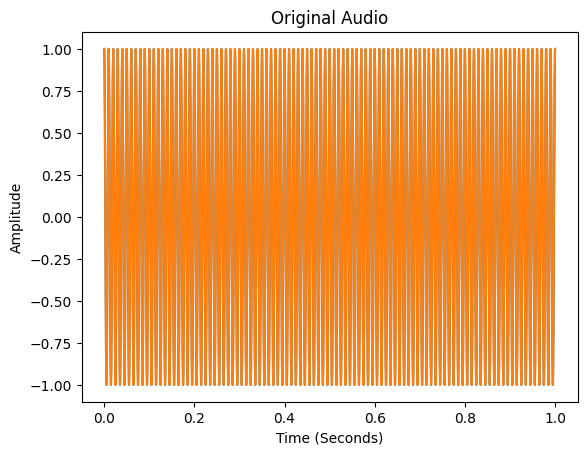

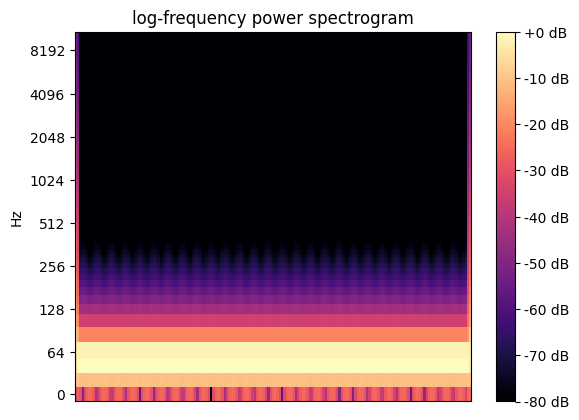

In [133]:
frequency = 100
sr = 44100
numHarmonics = 100
waveType = 'sine'
winSize = 1024
specType = 'log'

signal = visualizeWaveforms(frequency , sr , numHarmonics , waveType , winSize , specType)
IPython.display.Audio(signal , rate=sr)

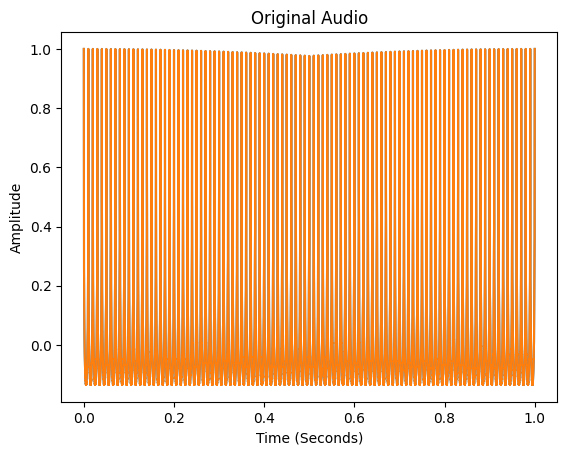

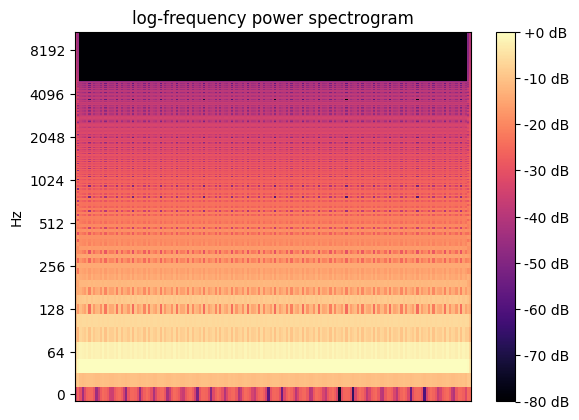

In [134]:
frequency = 100
sr = 44100
numHarmonics = 100
waveType = 'sawtooth'
winSize = 1024
specType = 'log'

signal = visualizeWaveforms(frequency , sr , numHarmonics , waveType , winSize , specType)
IPython.display.Audio(signal , rate=sr)

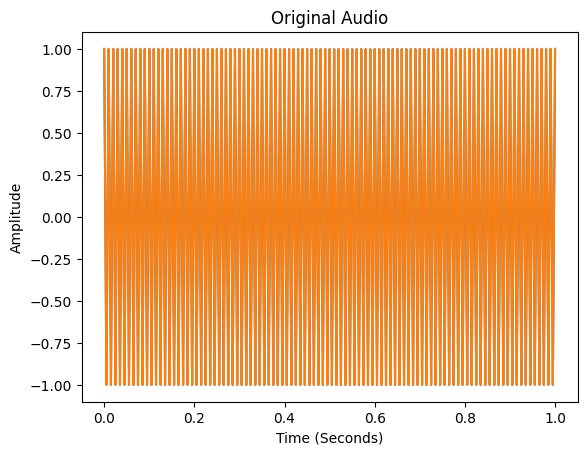

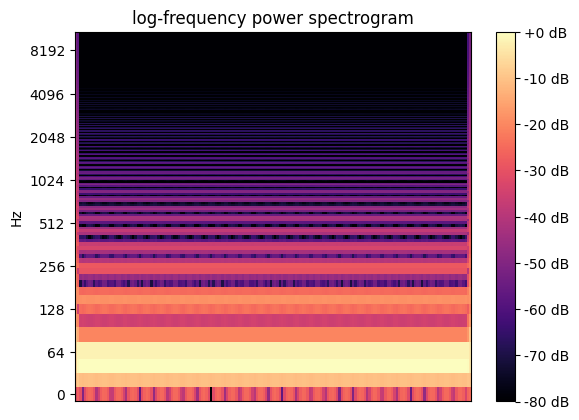

In [135]:
frequency = 100
sr = 44100
numHarmonics = 100
waveType = 'triangle'
winSize = 1024
specType = 'log'

signal = visualizeWaveforms(frequency , sr , numHarmonics , waveType , winSize , specType)
IPython.display.Audio(signal , rate=sr)

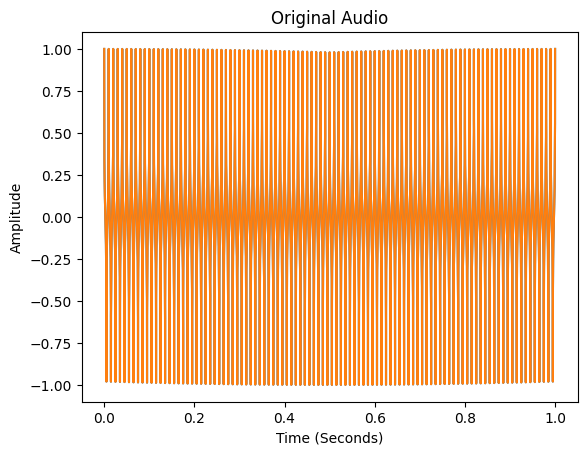

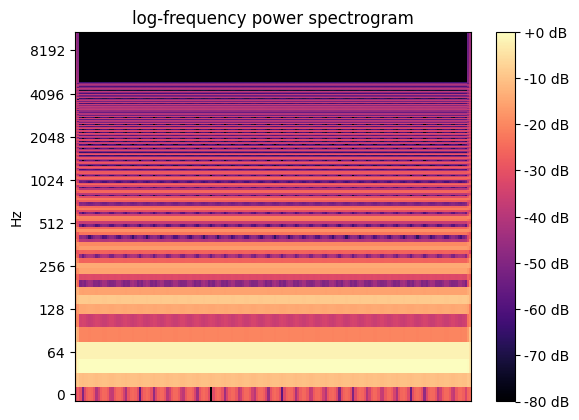

In [137]:
frequency = 100
sr = 44100
numHarmonics = 100
waveType = 'square'
winSize = 1024
specType = 'log'

signal = visualizeWaveforms(frequency , sr , numHarmonics , waveType , winSize , specType)
IPython.display.Audio(signal , rate=sr)